# 1. IMPORT LIBRARIES + DATASET

In [1]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
deposit = pd.read_csv("Data_Deposit.csv")

# 2. FIRST GLANCE

In [3]:
# 5 dòng đầu
deposit.head()

,MONTH,COUNT_CA_ACCT,AVG_CA_BALANCE,COUNT_TD_ACCT,AVG_TD_BALANCE,CUSTOMER_NUMBER
0,1/31/2019,1,246774.19,0,0.0,914393
1,2/28/2019,1,209207.36,0,0.0,914393
2,3/31/2019,1,213225.90,0,0.0,914393
3,4/30/2019,1,211761.87,0,0.0,914393
4,5/31/2019,1,222391.16,0,0.0,914393


In [4]:
# 10 dòng ngẫu nhiên
deposit.sample(10)

,MONTH,COUNT_CA_ACCT,AVG_CA_BALANCE,COUNT_TD_ACCT,AVG_TD_BALANCE,CUSTOMER_NUMBER
813067,8/31/2019,1,1131061.29,0,0.0,66225
1252176,12/31/2019,1,51612.90,0,0.0,107174
49089,5/31/2019,1,9823151.58,0,0.0,835301
347720,11/30/2019,1,10198.00,1,15000000.0,530875
367621,4/30/2019,1,2350211.80,0,0.0,273800
688115,10/31/2019,1,168961.29,0,0.0,215183
122408,5/31/2019,1,426583.87,0,0.0,430412
225318,12/31/2019,1,463762.90,0,0.0,165182
82514,2/28/2019,1,2266231.43,0,0.0,944142
739522,6/30/2019,1,282600.00,0,0.0,283323


In [5]:
# Mô tả dữ liệu
print("--- DESCRIPTION ---")
deposit.describe(include = "all")

--- DESCRIPTION ---


,MONTH,COUNT_CA_ACCT,AVG_CA_BALANCE,COUNT_TD_ACCT,AVG_TD_BALANCE,CUSTOMER_NUMBER
count,1258424,1.258424e+06,1.258424e+06,1.258424e+06,1.258424e+06,1.258424e+06
unique,12,NaN,NaN,NaN,NaN,NaN
top,12/31/2019,NaN,NaN,NaN,NaN,NaN
freq,215746,NaN,NaN,NaN,NaN,NaN
mean,NaN,9.362313e-01,4.744692e+06,2.181848e-01,4.959629e+07,5.012424e+05
std,NaN,2.820505e-01,7.254613e+07,6.900133e-01,4.417742e+08,2.887806e+05
min,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,1.000000e+00,8.635484e+04,0.000000e+00,0.000000e+00,2.511150e+05
50%,NaN,1.000000e+00,2.897488e+05,0.000000e+00,0.000000e+00,5.020280e+05
75%,NaN,1.000000e+00,1.334255e+06,0.000000e+00,0.000000e+00,7.511750e+05


In [6]:
# Thông tin cơ bản
print("--- INFORMATION ---")
deposit.info()

--- INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258424 entries, 0 to 1258423
Data columns (total 6 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   MONTH            1258424 non-null  object 
 1   COUNT_CA_ACCT    1258424 non-null  int64  
 2   AVG_CA_BALANCE   1258424 non-null  float64
 3   COUNT_TD_ACCT    1258424 non-null  int64  
 4   AVG_TD_BALANCE   1258424 non-null  float64
 5   CUSTOMER_NUMBER  1258424 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 57.6+ MB


In [7]:
# Kích thước
print("--- SHAPE ---")
print(f"Số dòng: {deposit.shape[0]} dòng")
print(f"Số cột: {deposit.shape[1]} cột")

--- SHAPE ---
Số dòng: 1258424 dòng
Số cột: 6 cột


In [8]:
# Kiểm tra dữ liệu thiếu
print("--- CHECK MISSING VALUE ---")
deposit.isna().sum()

--- CHECK MISSING VALUE ---


MONTH              0
COUNT_CA_ACCT      0
AVG_CA_BALANCE     0
COUNT_TD_ACCT      0
AVG_TD_BALANCE     0
CUSTOMER_NUMBER    0
dtype: int64

# 3. DATA CLEANING

In [9]:
deposit["MONTH"] = pd.to_datetime(deposit["MONTH"], errors = "coerce")
deposit = deposit.sort_values(["CUSTOMER_NUMBER", "MONTH"])
deposit.head(10)

,MONTH,COUNT_CA_ACCT,AVG_CA_BALANCE,COUNT_TD_ACCT,AVG_TD_BALANCE,CUSTOMER_NUMBER
1095133,2019-09-30,1,57364833.33,0,0.0,0
1095134,2019-10-31,1,750812.90,0,0.0,0
1095135,2019-11-30,1,5280833.33,0,0.0,0
1095136,2019-12-31,1,29460361.29,0,0.0,0
531258,2019-05-31,1,265089.26,0,0.0,3
531259,2019-06-30,1,689391.60,0,0.0,3
531260,2019-07-31,1,488723.32,0,0.0,3
531261,2019-08-31,1,391159.00,0,0.0,3
531262,2019-09-30,1,465138.10,0,0.0,3
531263,2019-10-31,1,396822.84,0,0.0,3


In [10]:
cutoff_date = pd.Timestamp("2019-10-01")
deposit_obs = deposit[deposit["MONTH"] < cutoff_date].copy()

## 3.1.0. Kiểm tra chất lượng dữ liệu: CUSTOMER_NUMBER bất thường

Trong dữ liệu gốc có một vài dòng với `CUSTOMER_NUMBER = 0`, chỉ xuất hiện từ tháng 9/2019 trở đi. Đây nhiều khả năng là mã placeholder/lỗi hệ thống chứ không phải khách hàng thật, nên cần loại trước khi tổng hợp để tránh làm bẩn lending_feature_table khi merge với bảng khách hàng tổng ở bước sau.

In [11]:
n_invalid = (deposit_obs["CUSTOMER_NUMBER"] == 0).sum()
print(f"Số dòng có CUSTOMER_NUMBER = 0: {n_invalid}")

deposit_obs = deposit_obs[deposit_obs["CUSTOMER_NUMBER"] != 0].copy()
print(f"Số dòng còn lại sau khi loại: {len(deposit_obs)}")

Số dòng có CUSTOMER_NUMBER = 0: 1
Số dòng còn lại sau khi loại: 667588


## 3.1.1. Xử lý outlier AVG_CA_BALANCE / AVG_TD_BALANCE

Cả hai số dư đều lệch phải rất mạnh (AVG_CA_BALANCE tới ~26 tỷ, AVG_TD_BALANCE tới ~125.5 tỷ trong khi median chỉ vài trăm nghìn). Winsorize (cap) tại percentile 99.5%, tính trên chính observation window để không leak từ performance window.

In [12]:
ca_cap = deposit_obs["AVG_CA_BALANCE"].quantile(0.995)
td_cap = deposit_obs["AVG_TD_BALANCE"].quantile(0.995)

n_ca_capped = (deposit_obs["AVG_CA_BALANCE"] > ca_cap).sum()
n_td_capped = (deposit_obs["AVG_TD_BALANCE"] > td_cap).sum()

deposit_obs["AVG_CA_BALANCE_CAPPED"] = deposit_obs["AVG_CA_BALANCE"].clip(upper=ca_cap)
deposit_obs["AVG_TD_BALANCE_CAPPED"] = deposit_obs["AVG_TD_BALANCE"].clip(upper=td_cap)

print(f"Ngưỡng cap CA (99.5%): {ca_cap:,.0f} | số dòng bị cap: {n_ca_capped}")
print(f"Ngưỡng cap TD (99.5%): {td_cap:,.0f} | số dòng bị cap: {n_td_capped}")

Ngưỡng cap CA (99.5%): 135,705,367 | số dòng bị cap: 3338
Ngưỡng cap TD (99.5%): 1,487,408,433 | số dòng bị cap: 3338


Minh hoạ phân phối trước/sau log-transform cho cả hai loại số dư.

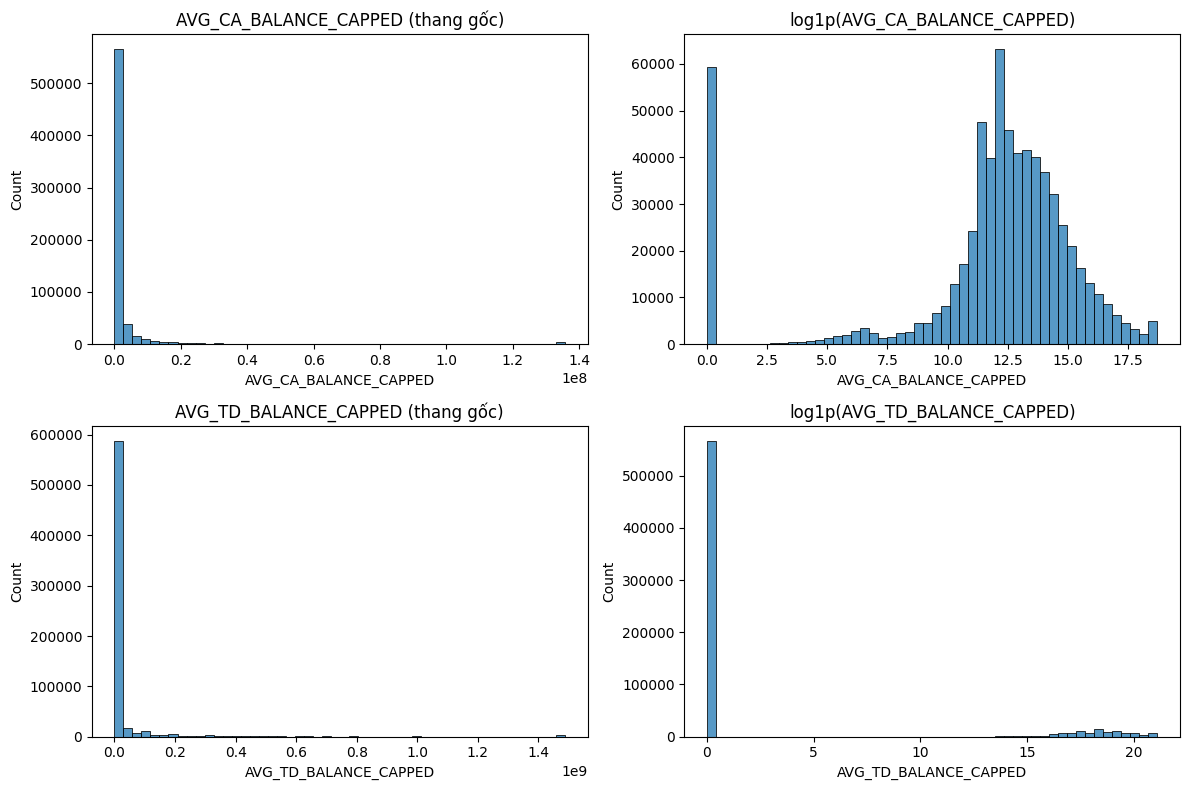

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(deposit_obs["AVG_CA_BALANCE_CAPPED"], bins=50, ax=axes[0,0])
axes[0,0].set_title("AVG_CA_BALANCE_CAPPED (thang gốc)")

sns.histplot(np.log1p(deposit_obs["AVG_CA_BALANCE_CAPPED"]), bins=50, ax=axes[0,1])
axes[0,1].set_title("log1p(AVG_CA_BALANCE_CAPPED)")

sns.histplot(deposit_obs["AVG_TD_BALANCE_CAPPED"], bins=50, ax=axes[1,0])
axes[1,0].set_title("AVG_TD_BALANCE_CAPPED (thang gốc)")

sns.histplot(np.log1p(deposit_obs["AVG_TD_BALANCE_CAPPED"]), bins=50, ax=axes[1,1])
axes[1,1].set_title("log1p(AVG_TD_BALANCE_CAPPED)")

plt.tight_layout()
plt.show()

In [14]:
idx_latest_dep = deposit_obs.groupby("CUSTOMER_NUMBER")["MONTH"].idxmax()
feat_deposit_snapshot = deposit_obs.loc[idx_latest_dep, [
    "CUSTOMER_NUMBER", "COUNT_CA_ACCT", "AVG_CA_BALANCE_CAPPED", "COUNT_TD_ACCT", "AVG_TD_BALANCE_CAPPED"
]].copy()

feat_deposit_snapshot.rename(columns = {
    "COUNT_CA_ACCT": "LATEST_CA_COUNT", 
    "AVG_CA_BALANCE_CAPPED": "LATEST_AVG_CA_BALANCE",
    "COUNT_TD_ACCT": "LATEST_TD_COUNT",
    "AVG_TD_BALANCE_CAPPED": "LATEST_AVG_TD_BALANCE"
}, inplace = True)

# Log-transform song song với bản gốc (phân phối lệch phải mạnh)
feat_deposit_snapshot["LOG_LATEST_AVG_CA_BALANCE"] = np.log1p(feat_deposit_snapshot["LATEST_AVG_CA_BALANCE"])
feat_deposit_snapshot["LOG_LATEST_AVG_TD_BALANCE"] = np.log1p(feat_deposit_snapshot["LATEST_AVG_TD_BALANCE"])

# Tạo cờ nhị phân — khác với bảng lending, ở đây deposit_obs có cả dòng COUNT_CA_ACCT/COUNT_TD_ACCT = 0,
# nên 2 cờ này thực sự phân biệt được khách có/không có sản phẩm, không phải hằng số.
feat_deposit_snapshot["HAS_CA_OBS"] = (feat_deposit_snapshot["LATEST_CA_COUNT"] > 0).astype(int)
feat_deposit_snapshot["HAS_TD_OBS"] = (feat_deposit_snapshot["LATEST_TD_COUNT"] > 0).astype(int)

feat_deposit_snapshot

,CUSTOMER_NUMBER,LATEST_CA_COUNT,LATEST_AVG_CA_BALANCE,LATEST_TD_COUNT,LATEST_AVG_TD_BALANCE,LOG_LATEST_AVG_CA_BALANCE,LOG_LATEST_AVG_TD_BALANCE,HAS_CA_OBS,HAS_TD_OBS
531262,3,1,465138.10,0,0.0,13.050092,0.000000,1,0
1019436,4,1,514166.00,1,150000000.0,13.150303,18.826146,1,1
852921,7,1,975015.47,0,0.0,13.790210,0.000000,1,0
1096379,16,1,20000.00,0,0.0,9.903538,0.000000,1,0
874176,32,1,250000.00,0,0.0,12.429220,0.000000,1,0
...,...,...,...,...,...,...,...,...,...
766562,999966,1,993333.33,0,0.0,13.808823,0.000000,1,0
322777,999969,1,1150330.43,0,0.0,13.955561,0.000000,1,0
1026260,999975,1,482904.55,0,0.0,13.087576,0.000000,1,0
811686,999977,1,4891233.33,0,0.0,15.402955,0.000000,1,0


In [15]:
# Trích xuất LỊCH SỬ VÀ QUY MÔ (History & Volume)
deposit_history = deposit_obs.groupby("CUSTOMER_NUMBER").agg(
    DEPOSIT_ACTIVE_MONTHS = ("MONTH", "nunique"),
    MAX_HIST_CA_BALANCE = ("AVG_CA_BALANCE_CAPPED", "max"),
    MEAN_HIST_CA_BALANCE = ("AVG_CA_BALANCE_CAPPED", "mean"),
    MAX_HIST_TD_BALANCE = ("AVG_TD_BALANCE_CAPPED", "max"),
    MEAN_HIST_TD_BALANCE = ("AVG_TD_BALANCE_CAPPED", "mean")
).reset_index()

# Log-transform song song với bản gốc (phân phối lệch phải mạnh)
deposit_history["LOG_MAX_HIST_CA_BALANCE"] = np.log1p(deposit_history["MAX_HIST_CA_BALANCE"])
deposit_history["LOG_MEAN_HIST_CA_BALANCE"] = np.log1p(deposit_history["MEAN_HIST_CA_BALANCE"])
deposit_history["LOG_MAX_HIST_TD_BALANCE"] = np.log1p(deposit_history["MAX_HIST_TD_BALANCE"])
deposit_history["LOG_MEAN_HIST_TD_BALANCE"] = np.log1p(deposit_history["MEAN_HIST_TD_BALANCE"])

In [16]:
# Tính xu hướng tăng trưởng số dư
first_dep = deposit_obs.groupby("CUSTOMER_NUMBER").first().reset_index()
last_dep = deposit_obs.groupby("CUSTOMER_NUMBER").last().reset_index()

# Số tháng giữa lần quan sát đầu và cuối trong observation window (để chuẩn hoá growth theo thời gian)
months_elapsed = (
    (last_dep["MONTH"].dt.year - first_dep["MONTH"].dt.year) * 12
    + (last_dep["MONTH"].dt.month - first_dep["MONTH"].dt.month)
)
months_elapsed_safe = months_elapsed.replace(0, np.nan)

ca_growth = last_dep["AVG_CA_BALANCE_CAPPED"] - first_dep["AVG_CA_BALANCE_CAPPED"]
td_growth = last_dep["AVG_TD_BALANCE_CAPPED"] - first_dep["AVG_TD_BALANCE_CAPPED"]

# Recency: số tháng từ lần quan sát gần nhất tới cutoff_date
recency_months = (
    (cutoff_date.year - last_dep["MONTH"].dt.year) * 12
    + (cutoff_date.month - last_dep["MONTH"].dt.month)
)

growth_dep_df = pd.DataFrame({
    "CUSTOMER_NUMBER": first_dep["CUSTOMER_NUMBER"],
    "CA_BALANCE_GROWTH": ca_growth,
    "TD_BALANCE_GROWTH": td_growth,
    # Tốc độ tăng trưởng/tháng, chuẩn hoá theo số tháng đã trôi qua giữa lần quan sát đầu và cuối
    "CA_BALANCE_GROWTH_RATE": (ca_growth / months_elapsed_safe).fillna(0),
    "TD_BALANCE_GROWTH_RATE": (td_growth / months_elapsed_safe).fillna(0),
    "RECENCY_MONTHS": recency_months
})
deposit_history = deposit_history.merge(growth_dep_df, on = "CUSTOMER_NUMBER", how = "left")

deposit_history

,CUSTOMER_NUMBER,DEPOSIT_ACTIVE_MONTHS,MAX_HIST_CA_BALANCE,MEAN_HIST_CA_BALANCE,MAX_HIST_TD_BALANCE,MEAN_HIST_TD_BALANCE,LOG_MAX_HIST_CA_BALANCE,LOG_MEAN_HIST_CA_BALANCE,LOG_MAX_HIST_TD_BALANCE,LOG_MEAN_HIST_TD_BALANCE,CA_BALANCE_GROWTH,TD_BALANCE_GROWTH,CA_BALANCE_GROWTH_RATE,TD_BALANCE_GROWTH_RATE,RECENCY_MONTHS
0,3,5,689391.60,4.599003e+05,0.000000e+00,0.000000e+00,13.443566,13.038767,0.000000,0.000000,200048.84,0.0,5.001221e+04,0.0,1
1,4,2,514166.00,3.317200e+05,1.500000e+08,9.677419e+07,13.150303,12.712050,18.826146,18.387891,364892.00,106451612.9,3.648920e+05,106451612.9,1
2,7,3,975015.47,8.521057e+05,0.000000e+00,0.000000e+00,13.790210,13.655467,0.000000,0.000000,84107.08,0.0,4.205354e+04,0.0,1
3,16,1,20000.00,2.000000e+04,0.000000e+00,0.000000e+00,9.903538,9.903538,0.000000,0.000000,0.00,0.0,0.000000e+00,0.0,1
4,32,3,250000.00,1.306452e+05,0.000000e+00,0.000000e+00,12.429220,11.780248,0.000000,0.000000,208064.52,0.0,1.040323e+05,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159435,999966,4,1115548.39,5.580538e+05,0.000000e+00,0.000000e+00,13.924858,13.232212,0.000000,0.000000,970000.00,0.0,3.233333e+05,0.0,1
159436,999969,7,13933383.63,2.944756e+06,9.677419e+07,1.382488e+07,16.449798,14.895537,18.387891,16.441981,1086523.98,0.0,1.810873e+05,0.0,1
159437,999975,1,482904.55,4.829045e+05,0.000000e+00,0.000000e+00,13.087576,13.087576,0.000000,0.000000,0.00,0.0,0.000000e+00,0.0,2
159438,999977,3,4891233.33,1.963239e+06,0.000000e+00,0.000000e+00,15.402955,14.490107,0.000000,0.000000,4485846.23,0.0,2.242923e+06,0.0,1


In [17]:
deposit_clean = feat_deposit_snapshot.merge(deposit_history, on = "CUSTOMER_NUMBER", how = "outer").fillna(0)
deposit_clean.to_csv("deposit_clean.csv", index = False)

print(f"Xử lý xong Deposit Features! Kích thước: {deposit_clean.shape}")
deposit_clean.head()

Xử lý xong Deposit Features! Kích thước: (159440, 23)


,CUSTOMER_NUMBER,LATEST_CA_COUNT,LATEST_AVG_CA_BALANCE,LATEST_TD_COUNT,LATEST_AVG_TD_BALANCE,LOG_LATEST_AVG_CA_BALANCE,LOG_LATEST_AVG_TD_BALANCE,HAS_CA_OBS,HAS_TD_OBS,DEPOSIT_ACTIVE_MONTHS,...,MEAN_HIST_TD_BALANCE,LOG_MAX_HIST_CA_BALANCE,LOG_MEAN_HIST_CA_BALANCE,LOG_MAX_HIST_TD_BALANCE,LOG_MEAN_HIST_TD_BALANCE,CA_BALANCE_GROWTH,TD_BALANCE_GROWTH,CA_BALANCE_GROWTH_RATE,TD_BALANCE_GROWTH_RATE,RECENCY_MONTHS
0,3,1,465138.10,0,0.0,13.050092,0.000000,1,0,5,...,0.00,13.443566,13.038767,0.000000,0.000000,200048.84,0.0,50012.21,0.0,1
1,4,1,514166.00,1,150000000.0,13.150303,18.826146,1,1,2,...,96774193.55,13.150303,12.712050,18.826146,18.387891,364892.00,106451612.9,364892.00,106451612.9,1
2,7,1,975015.47,0,0.0,13.790210,0.000000,1,0,3,...,0.00,13.790210,13.655467,0.000000,0.000000,84107.08,0.0,42053.54,0.0,1
3,16,1,20000.00,0,0.0,9.903538,0.000000,1,0,1,...,0.00,9.903538,9.903538,0.000000,0.000000,0.00,0.0,0.00,0.0,1
4,32,1,250000.00,0,0.0,12.429220,0.000000,1,0,3,...,0.00,12.429220,11.780248,0.000000,0.000000,208064.52,0.0,104032.26,0.0,1
